In [ ]:
from pathlib import Path
import os
import sys

# Resolve the repository root from the kernel working directory, or set CYCLOADD_REPO_ROOT.
repo_root_env = os.environ.get("CYCLOADD_REPO_ROOT")
if repo_root_env:
    REPO_ROOT = Path(repo_root_env).expanduser().resolve()
    if not (REPO_ROOT / "Code").is_dir() or not (REPO_ROOT / "Data").is_dir():
        raise RuntimeError(f"CYCLOADD_REPO_ROOT is not a repository root: {REPO_ROOT}")
else:
    REPO_ROOT = next(
        (parent for parent in (Path.cwd(), *Path.cwd().parents)
         if (parent / "Code").is_dir() and (parent / "Data").is_dir()),
        None,
    )
if REPO_ROOT is None:
    raise RuntimeError("Start Jupyter in this repository or set CYCLOADD_REPO_ROOT")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

# External calculation directories can be changed without moving this notebook.
SMILES_DIR = os.environ.get("CYCLOADD_SMILES_DIR", r"G:\work\Secondary_Selection\Diene_Ene_Smiles")
PRED_CSV_DIR = os.environ.get("CYCLOADD_PRED_CSV_DIR", r"G:\work\Secondary_Selection\All_possible_DA_ZINC")
REACTION_WORK_DIR = os.environ.get("CYCLOADD_REACTION_WORK_DIR", r"G:\work\Secondary_Selection\ZINC_1")
REACTION_RESULT_CSV = os.environ.get("CYCLOADD_REACTION_RESULT_CSV", os.path.join(REACTION_WORK_DIR, "Result_.csv"))

import glob, shutil
from tqdm import tqdm
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

from Code import cycle_process

diene: means 4π

ene: means 2π

In [ ]:
ZINC_SMILES_FILE = "Data/ZINC_Data/ZINC/*/*.smi"
ALL_SMILES_CSV = r"Data/ZINC_Data/all_smiles.csv"
DESC_FILE = r"Data/DFT_Result/Descriptors_Filter.pkl"

# 0 Collection Smiles From ZINC

In [8]:
# .smi are not include in Github, Download it from https://zinc20.docking.org/
all_smis = glob.glob(ZINC_SMILES_FILE)
target_smis = set()
for smi in all_smis:
    with open(smi) as f:
        lines = f.readlines()
        for line in lines:
            if line.split()[0] == "smiles":
                continue
            target_smis.add(line.split()[0])
with open("Data/ZINC_Data/all_smiles.smi", 'wt') as f:
    for smi in target_smis:
        f.write(smi + "\n")

In [13]:
target_smis = []
with open("Data/ZINC_Data/all_smiles.smi") as f:
    for eachline in f.readlines():
        target_smis.append(eachline.strip())

# 1 Select 4π and 2π

In [50]:
diene_smiles = set()
ene_smiles = set()
diene_smart = Chem.MolFromSmarts("*=**=*")
ene_smart =  Chem.MolFromSmarts("*=*")
for smi in tqdm(target_smis):
    if "B" in smi or "+" in smi or "-" in smi:
        continue
    mol = Chem.MolFromSmiles(smi)
    smi = Chem.MolToSmiles(mol)
    if mol.GetNumAtoms() > 10:
        continue
    if len([each for each in mol.GetAtoms() if each.GetAtomicNum() > 10]) > 0:
        continue
    if len([each for each in mol.GetAtoms() if each.GetNumRadicalElectrons() != 0]) > 0:
        continue
    Chem.Kekulize(mol, clearAromaticFlags=True)
    if mol.HasSubstructMatch(diene_smart):
        if cycle_process.is_diene(smi):
            diene_smiles.add(smi)
    if mol.HasSubstructMatch(ene_smart):
        ene_smiles.add(smi)
diene_smiles = list(diene_smiles)
diene_smiles.sort()
ene_smiles = list(ene_smiles)
ene_smiles.sort()
with open("Data/ZINC_Data/all_diene.smi", 'wt') as f:
    for smi in diene_smiles:
        f.write(smi + "\n")
with open("Data/ZINC_Data/all_ene.smi", 'wt') as f:
    for smi in ene_smiles:
        f.write(smi + "\n")

  1%|          | 7332/855366 [00:00<01:32, 9203.57it/s]

100%|██████████| 855366/855366 [01:30<00:00, 9441.85it/s]


In [ ]:
def select_smiles_by_fp(all_smiles, select_num = 3000, pre_smiles=[], banned_smiles=[], seed=1):
    """select smiles by MorganFingerprint Similarity

    Args:
        file_dir (_type_): smiles file

    Returns:
        _type_: _description_
    """    
        
    all_smiles = list(set(all_smiles) | set(pre_smiles))
    all_smiles = [smiles for smiles in all_smiles if smiles not in banned_smiles] 
    fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(each), radius=4, nBits=4096) for each in tqdm(all_smiles)]
    picker = MaxMinPicker()
    first_picks = [all_smiles.index(each) for each in pre_smiles]
    pick_idx = picker.LazyBitVectorPick(fps, len(all_smiles), select_num, firstPicks=first_picks)
    pick_smiles = [all_smiles[each] for each in pick_idx]
    return pick_smiles, pick_idx
diene_picked_smiles = select_smiles_by_fp(diene_smiles, 3000, pre_smiles=['c1nncnn1'], seed=1)[0]
ene_picked_smiles = select_smiles_by_fp(ene_smiles, 3000, pre_smiles=["C1=C/CCCCCC/1", "C1=CC2CCC1CC2"], seed=1)[0]
with open("Data/ZINC_Data/all_selected_diene.smi", 'wt') as f:
    for smi in diene_picked_smiles:
        f.write(smi + "\n")
with open("Data/ZINC_Data/all_selected_ene.smi", 'wt') as f:
    for smi in ene_picked_smiles:
        f.write(smi + "\n")

100%|██████████| 31115/31115 [00:02<00:00, 11968.36it/s]


In [ ]:
diene_picked_smiles = []
with open("Data/ZINC_Data/all_selected_diene.smi") as f:
    for eachline in f.readlines():
        diene_picked_smiles.append(eachline.strip())
ene_picked_smiles = []
with open("Data/ZINC_Data/all_selected_ene.smi") as f:
    for eachline in f.readlines():
        ene_picked_smiles.append(eachline.strip())

In [ ]:
ene_picked_smiles_ = sorted(ene_picked_smiles)
diene_picked_smiles_ = sorted(diene_picked_smiles)


In [ ]:
# Ethylene (C=C) is introduced later as the reference 2π partner in the reaction-pair table.
# Keep the two selected lists at 3,000 entries each for the side-by-side CSV below.


In [ ]:
df = pd.DataFrame({"Diene": diene_picked_smiles_, "Ene": ene_picked_smiles_})
df.to_csv("Data/ZINC_Data/all_selected_smiles.csv", index=False)

# 2. DFT Calculate the Reactants

Run [reactant DFT](../02_quantum/01_reactant_dft.ipynb), then [reactant descriptors](../02_quantum/02_reactant_descriptors.ipynb). Set `SMILES_DIR` in each notebook to the same calculation directory.


Copy the resulting `SMILES_DIR/all_smiles.csv` to `Data/ZINC_Data/all_smiles.csv` after checking the calculation version.


The descriptor notebook writes `Descriptors_.pkl`; later pair generation uses a separately named `all_property_detailSterimol_witharea.pkl`. Confirm the required descriptor version before copying any map to `Data/DFT_Result/Descriptors_Filter.pkl`.


# 3. Select the 4π systems that form stable reaction products with ethylene and the 2π systems that form stable reaction products with butadiene.

## 3.1 Collect the reactants that successfully underwent DFT optimization without errors.

In [ ]:
select_diene_csvid = []
select_ene_csvid = []
selected_diene = []
selected_ene = []
all_smiles_csv = pd.read_csv(ALL_SMILES_CSV)
for row_id, row in all_smiles_csv.iterrows():
    if row["Smiles"] in diene_picked_smiles_ and row["Smiles"] not in selected_diene:
        select_diene_csvid.append(row_id)
        selected_diene.append(row["Smiles"]) 
    if row["Smiles"] in ene_picked_smiles_ and row["Smiles"] not in selected_ene:
        select_ene_csvid.append(row_id)
        selected_ene.append(row["Smiles"])
all_smiles_csv.loc[select_diene_csvid].to_csv("Data/ZINC_Data/target_diene_raw.csv", index=False)
all_smiles_csv.loc[select_diene_csvid].dropna().to_csv("Data/ZINC_Data/target_diene.csv", index=False)
all_smiles_csv.loc[select_ene_csvid].to_csv("Data/ZINC_Data/target_ene_raw.csv", index=False)
all_smiles_csv.loc[select_ene_csvid].dropna().to_csv("Data/ZINC_Data/target_ene.csv", index=False)

## 3.2 Stability Analysis with Ethylene or Butadiene

In [ ]:
Dienes, Enes, Diene_Indexs, Ene_Indexs = [], [], [], []
# These IDs belong to the saved reactant table; verify them if that table is regenerated.
reference_smiles = all_smiles_csv.set_index('Index')['Smiles']
assert reference_smiles.loc[862] == 'C=C'
assert reference_smiles.loc[2209] == 'C=CC=C'
for row_id, row in pd.read_csv("Data/ZINC_Data/target_diene.csv").iterrows():
    Dienes.append(row["Smiles"])
    Enes.append('C=C')
    Diene_Indexs.append(row['Index'])
    Ene_Indexs.append(862)
for row_id, row in pd.read_csv("Data/ZINC_Data/target_ene.csv").iterrows():
    Enes.append(row["Smiles"])
    Dienes.append('C=CC=C')
    Ene_Indexs.append(row['Index'])
    Diene_Indexs.append(2209)
result_df = pd.DataFrame({"Diene": Dienes, "Ene": Enes, "Diene_Indexs": Diene_Indexs, "Ene_Indexs": Ene_Indexs})
result_df.to_csv("Data/ZINC_Data/target_diene_ene.csv", index=False)

Run [reaction DFT/TS/IRC](../02_quantum/04_reaction_dft_ts_irc.ipynb) for this reference-partner screening. Set `reaction_file_dir` to `Data/ZINC_Data/target_diene_ene.csv` and export the verified reaction result to `Data/ZINC_Data/target_diene_ene_Result.csv`. For the thermodynamic screen below, the reaction free-energy stage is sufficient.


In [11]:
df = pd.read_csv("Data/ZINC_Data/target_diene_ene_Result.csv")
df = df.loc[df['deltaG'] < 10]
passed_diene = np.sort(np.unique(df["Diene_Index"].to_numpy()))
passed_ene = np.sort(np.unique(df["Ene_Index"].to_numpy()))
len(passed_diene), len(passed_ene)

(718, 1790)

In [12]:
select_diene_csv = pd.read_csv("Data/ZINC_Data/target_diene.csv")
select_ene_csv = pd.read_csv("Data/ZINC_Data/target_ene.csv")
select_diene_csv = select_diene_csv.loc[select_diene_csv["Index"].isin(passed_diene)]
select_ene_csv = select_ene_csv.loc[select_ene_csv["Index"].isin(passed_ene)]
select_diene_csv.to_csv("Data/ZINC_Data/target_diene_passed.csv", index=False)
select_ene_csv.to_csv("Data/ZINC_Data/target_ene_passed.csv", index=False)

### 2.2.1 Generate the All Cross-Combination Dataset with passed 4π and 2π

Run [reaction pair and product generation](../02_quantum/03_reaction_pair_generation.ipynb) with the passed 4π/2π tables below. Its descriptor-map input is configured separately from the preceding descriptor notebook.


## 2.3 Use Similarity to Get The First Dataset (4000)

In [38]:
def generate_reaction_csv(picker_idx, select_diene_csv, select_ene_csv, target_idx):
    Dienes, Enes, Diene_Indexs, Ene_Indexs = [], [], [], []
    picker_idx = np.array(picker_idx)
    ene_num = len(select_ene_csv)
    for each in picker_idx:
        diene_row_id = each // ene_num
        ene_row_id = each % ene_num
        assert all_smis[target_idx[each][0]] == select_diene_csv["Smiles"][diene_row_id] and all_smis[target_idx[each][1]] == select_ene_csv["Smiles"][ene_row_id]
        Dienes.append(select_diene_csv["Smiles"][diene_row_id])
        Enes.append(select_ene_csv["Smiles"][ene_row_id])
        Diene_Indexs.append(select_diene_csv["Index"][diene_row_id])
        Ene_Indexs.append(select_ene_csv["Index"][ene_row_id])
    result_df = pd.DataFrame({"Diene": Dienes, "Ene": Enes, "Diene_Indexs": Diene_Indexs, "Ene_Indexs": Ene_Indexs})
    return result_df

In [2]:
select_diene_csv = pd.read_csv("Data/ZINC_Data/target_diene_passed.csv")
select_ene_csv = pd.read_csv("Data/ZINC_Data/target_ene_passed.csv")
all_smis = np.sort(np.unique(np.concatenate((select_diene_csv["Smiles"].values, select_ene_csv["Smiles"].values)))).tolist()
fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(each), 2, nBits=2048)) for each in all_smis])
mfps = fps @ fps.T
diene_indexs = [all_smis.index(row['Smiles']) for index, row in select_diene_csv.iterrows()]
ene_indexs = [all_smis.index(row['Smiles']) for index, row in select_ene_csv.iterrows()]
target_idx = np.array([[[a, b] for b in ene_indexs] for a in diene_indexs]).reshape(-1, 2)

In [3]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
def distanceij(i,j):
    diene_i, ene_i = target_idx[i]
    diene_j, ene_j = target_idx[j]
    # var_j = new_uncertainty[j]
    return (1 - generate_similarity(diene_i, ene_i, diene_j, ene_j)) # * rate + var_j

def generate_similarity(diene_i, ene_i, diene_j, ene_j):
    k = mfps[diene_i, diene_j] + mfps[ene_i, ene_j]
    return k / (mfps[diene_i, diene_i] + mfps[ene_i, ene_i] + mfps[diene_j, diene_j] + mfps[ene_j, ene_j] - k)

In [4]:
Times = 2
picker = MaxMinPicker()
picker_idx = picker.LazyPick(distanceij, len(target_idx), 4000, firstPicks=[])
# first_result = generate_reaction_csv(picker_idx, select_diene_csv, select_ene_csv, target_idx)
# np.save(f"Data/DFT_Result/picker_{Times:05}.npy", np.array(picker_idx))
# first_result.to_csv(f"Data/DFT_Result/iter_{Times:05}.csv", index=False)

KeyboardInterrupt: 

Run [reaction DFT/TS/IRC](../02_quantum/04_reaction_dft_ts_irc.ipynb) for this iteration. Set `reaction_file_dir` to `Data/DFT_Result/result_{Times:05}.csv`, then place the verified output at `Data/DFT_Result/result_{Times:05}_Result.csv`.


In [25]:
all_diene_indexs = np.unique(select_diene_csv["Index"].to_numpy())
all_ene_indexs = np.unique(select_ene_csv["Index"].to_numpy())
dft_csv = pd.read_csv(f"Data/DFT_Result/result_{Times:05}_Result.csv")
# dft_csv = pd.read_csv("Data/DFT_Result/result_00001.csv")._append(pd.read_csv("Data/DFT_Result/result_00002.csv"))

dfted_diene_indexs = np.unique(dft_csv["Diene_Index"].to_numpy())
dfted_ene_indexs = np.unique(dft_csv["Ene_Index"].to_numpy())
len(dfted_diene_indexs), len(all_diene_indexs), len(dfted_ene_indexs), len(all_ene_indexs)

(501, 718, 811, 1789)

## 2.4 Use Similarity to Get The Next Dataset (5000 + 500 + 500)

In [ ]:
smiles_dir = SMILES_DIR


In [2]:
import pickle
from catboost import CatBoostRegressor
def read_df(df):
    input_array = []
    idxs = []
    map_dir = smiles_dir + "/" + "all_property_detailSterimol_witharea.pkl"
    with open(map_dir, "rb") as f:
        target_map = pickle.load(f)
    for each in range(len(df)):
        temp_list = []
        diene_smiles = df.iloc[each]["Diene"]
        ene_smiles = df.iloc[each]["Ene"]
        diene_id = df.iloc[each]["Diene_Index"]
        ene_id = df.iloc[each]["Ene_Index"]
        title = df.iloc[each]["Title"]
        diene_atoma, diene_atomb, ene_atomc, ene_atomd, _, title_1 = [int(each) for each in title.split(" ")[:6]]
        diene_key = "%.5d %d %d %d" % (diene_id, 1, diene_atoma, diene_atomb)
        ene_key = "%.5d %d %d %d" % (ene_id, 0, ene_atomc, ene_atomd)
        if diene_key not in target_map.keys() or ene_key not in target_map.keys():
            continue
        diene_property = target_map[diene_key]
        ene_property = target_map[ene_key]
        diene_result = diene_property[-9:]
        result = ene_property[-8:]
        if title_1 == 0:
            result = [result[3], result[2], result[1], result[0], result[7], result[6], result[5], result[4]]
        temp_list += diene_property[:-9] + ene_property[:-8] + diene_result + result
        input_array.append(temp_list)
        idxs.append(each)
    return np.array(input_array), idxs

In [30]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
def distanceij(i,j):
    diene_i, ene_i = target_idx[i]
    diene_j, ene_j = target_idx[j]
    var_j = new_uncertainty[i]
    y_g_valiable = y_g_valiables[i]
    return 1 - generate_similarity(diene_i, ene_i, diene_j, ene_j) * 1 + var_j * 1 + y_g_valiable * 10

def generate_similarity(diene_i, ene_i, diene_j, ene_j):
    k = mfps[diene_i, diene_j] + mfps[ene_i, ene_j]
    return k / (mfps[diene_i, diene_i] + mfps[ene_i, ene_i] + mfps[diene_j, diene_j] + mfps[ene_j, ene_j] - k)

In [ ]:
select_diene_csv = pd.read_csv("Data/ZINC_Data/target_diene_passed.csv")
select_ene_csv = pd.read_csv("Data/ZINC_Data/target_ene_passed.csv")
all_smis = np.sort(np.unique(np.concatenate((select_diene_csv["Smiles"].values, select_ene_csv["Smiles"].values)))).tolist()
fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(each), 2, nBits=2048)) for each in all_smis])
mfps = fps @ fps.T
diene_indexs = [all_smis.index(row['Smiles']) for index, row in select_diene_csv.iterrows()]
ene_indexs = [all_smis.index(row['Smiles']) for index, row in select_ene_csv.iterrows()]
target_idx = np.array([[[a, b] for b in ene_indexs] for a in diene_indexs]).reshape(-1, 2)

In [3]:
Times = 2
shutil.copy(f"Data/DFT_Result/result_{Times:05}_Result.csv", f"Data/DFT_Result/result_{Times:05}_sum_Result.csv")

'../Data/Iteration_Data/result_00002_sum_Result.csv'

In [4]:
def active_learning(Times):
    data_csv = glob.glob(f"Data/DFT_Result/result_{Times:05}_sum_Result.csv")[0]
    react_data = pd.read_csv(data_csv)
    react_data = data_csv.loc[~np.isnan(react_data["deltaGa(Solvent)"])]
    X, _ = read_df(react_data)
    Y_DD = react_data['Diene_Distort'].to_numpy()
    Y_ED = react_data['Ene_Distort'].to_numpy()
    Y_IN = react_data['Interaction'].to_numpy()
    X_remove = []
    X_remove = list(set(X_remove))
    X_removed = np.delete(X, X_remove, axis=1)
    model1 = CatBoostRegressor(iterations=10000, learning_rate=0.05, depth=6, verbose=0, loss_function='RMSEWithUncertainty')
    model2 = CatBoostRegressor(iterations=10000, learning_rate=0.05, depth=6, verbose=0, loss_function='RMSEWithUncertainty')
    model3 = CatBoostRegressor(iterations=10000, learning_rate=0.05, depth=6, verbose=0, loss_function='RMSEWithUncertainty')
    model1.fit(X_removed, Y_DD)
    model2.fit(X_removed, Y_ED)
    model3.fit(X_removed, Y_IN)

    files = glob.glob(os.path.join(PRED_CSV_DIR, "Diene_*.npy"))
    for file_ in tqdm(files):
        X_1 = np.load(file_)
        X_new, idxs = X_1[:, :-1], X_1[:, -1].flatten().tolist()
        X_removed_new = np.delete(X_new, X_remove, axis=1)
        y_dd_mean, y_dd_var = model1.predict(X_removed_new).T
        y_ed_mean, y_ed_var = model2.predict(X_removed_new).T
        y_in_mean, y_in_var = model3.predict(X_removed_new).T
        csv_file = file_.replace("_des.npy", ".csv")
        df = pd.read_csv(csv_file)
        df[f'Times_{Times}_Diene_Distort_var'] = y_dd_var
        df[f'Times_{Times}_Ene_Distort_var'] = y_ed_var
        df[f'Times_{Times}_Interaction_var'] = y_in_var
        df = pd.DataFrame(df)
        df.to_csv(csv_file, index=False)
    new_uncertainty = []
    y_g_valiables = []
    for diene_index in tqdm(select_diene_csv['Index']):
        csv_file = os.path.join(PRED_CSV_DIR, f"Diene_Index_{diene_index:05}.csv")
        df = pd.read_csv(csv_file)
        for ene_index in select_ene_csv['Index']:
            temp_df = df.loc[df['Ene_Index'] == ene_index]
            new_uncertainty.append(np.max([temp_df[f'Times_{Times}_Diene_Distort_var'].to_numpy(), temp_df[f'Times_{Times}_Ene_Distort_var'].to_numpy(), temp_df[f'Times_{Times}_Interaction_var'].to_numpy()]))
            y_g_valiables.append(int(np.min(temp_df[f'Times_{Times}_G_mean'].to_numpy()) < 10))
    first_picker = np.load(f"Data/DFT_Result/picker_{Times:05}.npy")
    Times += 1
    picker = MaxMinPicker()
    picker_idx = picker.LazyPick(distanceij, len(target_idx), len(first_picker) + 500, firstPicks=first_picker.tolist())
    first_result = generate_reaction_csv(np.array(picker_idx)[len(first_picker):], select_diene_csv, select_ene_csv, target_idx)
    np.save(f"Data/DFT_Result/picker_{Times:05}.npy", np.array(picker_idx))
    first_result.to_csv(f"Data/DFT_Result/result_{Times:05}.csv", index=False)

In [12]:
active_learning(Times=2)

100%|██████████| 718/718 [04:30<00:00,  2.65it/s]


Run [reaction DFT/TS/IRC](../02_quantum/04_reaction_dft_ts_irc.ipynb) for this iteration. Set `reaction_file_dir` to `Data/DFT_Result/result_{Times:05}.csv`, then place the verified output at `Data/DFT_Result/result_{Times:05}_Result.csv`.


In [8]:
Times = 3
csv_1 = pd.read_csv(rf"Data/DFT_Result/result_{Times-1:05}_sum_Result.csv")
csv_2 = pd.read_csv(rf"Data/DFT_Result/result_{Times:05}_Result.csv")
csv_3 = csv_1._append(csv_2)
csv_3.to_csv(rf"Data/DFT_Result/result_{Times:05}_sum_Result.csv")

C:\Users\Jackie\AppData\Local\Temp\ipykernel_17292\951922630.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_1 = pd.read_csv(rf"../Data/Iteration_Data/result_{Times-1:05}_sum_Result.csv")


In [ ]:
active_learning(Times=3)

Run [reaction DFT/TS/IRC](../02_quantum/04_reaction_dft_ts_irc.ipynb) for this iteration. Set `reaction_file_dir` to `Data/DFT_Result/result_{Times:05}.csv`, then place the verified output at `Data/DFT_Result/result_{Times:05}_Result.csv`.


In [9]:
Times = 4
csv_1 = pd.read_csv(rf"Data/DFT_Result/result_{Times-1:05}_sum_Result.csv")
csv_2 = pd.read_csv(rf"Data/DFT_Result/result_{Times:05}_Result.csv")
csv_3 = csv_1._append(csv_2)
csv_3.to_csv(rf"Data/DFT_Result/result_{Times:05}_sum_Result.csv")

C:\Users\Jackie\AppData\Local\Temp\ipykernel_17292\3263434479.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  csv_1 = pd.read_csv(rf"../Data/Iteration_Data/result_{Times-1:05}_sum_Result.csv")


In [ ]:
RXN_csv = pd.read_csv(rf"Data/DFT_Result/result_{Times:05}_sum_Result.csv")
RXN_csv = RXN_csv.loc[~np.isnan(RXN_csv['deltaG'])]
RXN_csv.to_csv("RXN.csv")
dGa_csv = RXN_csv.loc[~np.isnan(RXN_csv['deltaGa(Solvent)'])]
dGa_csv.to_csv("Active_Energy.csv")

In [4]:
# dGa_csv = pd.read_csv("Data/DFT_Result/Active_Energy.csv")
RXN_csv = pd.read_csv("Data/DFT_Result/RXN.csv")
len(set(RXN_csv['Diene_Index'])), len(set(RXN_csv['Ene_Index']))

(718, 1786)

# The Next: Run 3_model_train.ipynb

## Reactant-space visualization

In [10]:
from sklearn import manifold
from matplotlib import pyplot as plt

In [2]:
all_diene_smiles = []
with open("Data/ZINC_Data/all_diene.smi") as f:
    for eachline in f.readlines():
        all_diene_smiles.append(eachline.strip())
all_ene_smiles = []
with open("Data/ZINC_Data/all_ene.smi") as f:
    for eachline in f.readlines():
        all_ene_smiles.append(eachline.strip())

In [ ]:
diene_picked_smiles = []
with open("Data/ZINC_Data/all_selected_diene.smi") as f:
    for eachline in f.readlines():
        diene_picked_smiles.append(eachline.strip())
ene_picked_smiles = []
with open("Data/ZINC_Data/all_selected_ene.smi") as f:
    for eachline in f.readlines():
        ene_picked_smiles.append(eachline.strip())

In [4]:
len(all_diene_smiles), len(all_ene_smiles), len(diene_picked_smiles), len(ene_picked_smiles)

(13028, 31115, 3000, 3000)

In [6]:
all_diene_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(each), 2, nBits=2048)) for each in all_diene_smiles])
all_ene_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(each), 2, nBits=2048)) for each in all_ene_smiles])

In [7]:
diene_select_id = [all_diene_smiles.index(each) for each in diene_picked_smiles]
ene_select_id = [all_ene_smiles.index(each) for each in ene_picked_smiles]

In [21]:
len(tsne_result)

13028

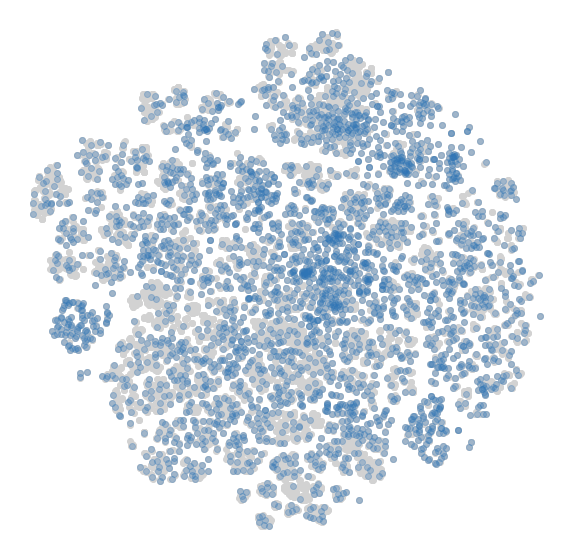

In [29]:
# tsne_result = manifold.TSNE(random_state=0).fit_transform(all_diene_fps)
plt.figure(figsize=(10, 10))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], color = (210/255, 210/255, 210/255), alpha=1, label='all diene')
plt.scatter(tsne_result[diene_select_id, 0], tsne_result[diene_select_id, 1], color = (46/255, 117/255, 182/255), alpha=0.3, label='select diene')
plt.axis('off')
plt.savefig('test.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
# plt.legend()

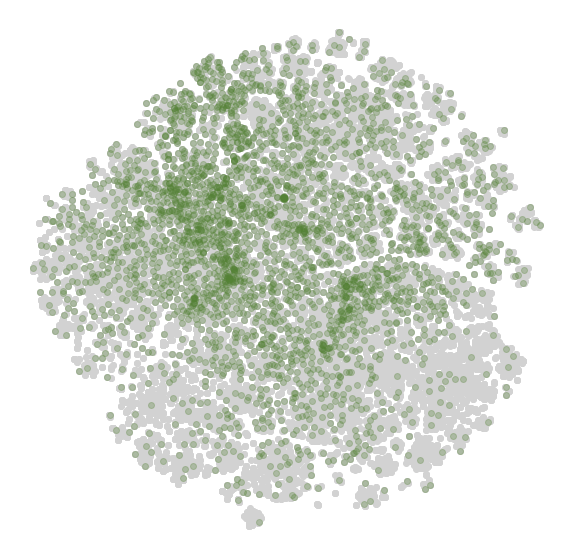

In [31]:
# tsne_result_ = manifold.TSNE(random_state=0).fit_transform(all_ene_fps)
plt.figure(figsize=(10, 10))
plt.scatter(tsne_result_[:, 0], tsne_result_[:, 1], color = (210/255, 210/255, 210/255), alpha=1, label='all ene')
plt.scatter(tsne_result_[ene_select_id, 0], tsne_result_[ene_select_id, 1], color = (84/255, 130/255, 53/255), alpha=0.3, label='select ene')
plt.axis('off')
plt.savefig('test2.png', dpi=300, bbox_inches='tight', pad_inches=0.1)

### SMILES to Image in SI

In [2]:
select_diene_csv = pd.read_csv("Data/ZINC_Data/target_diene_passed.csv")
select_ene_csv = pd.read_csv("Data/ZINC_Data/target_ene_passed.csv")

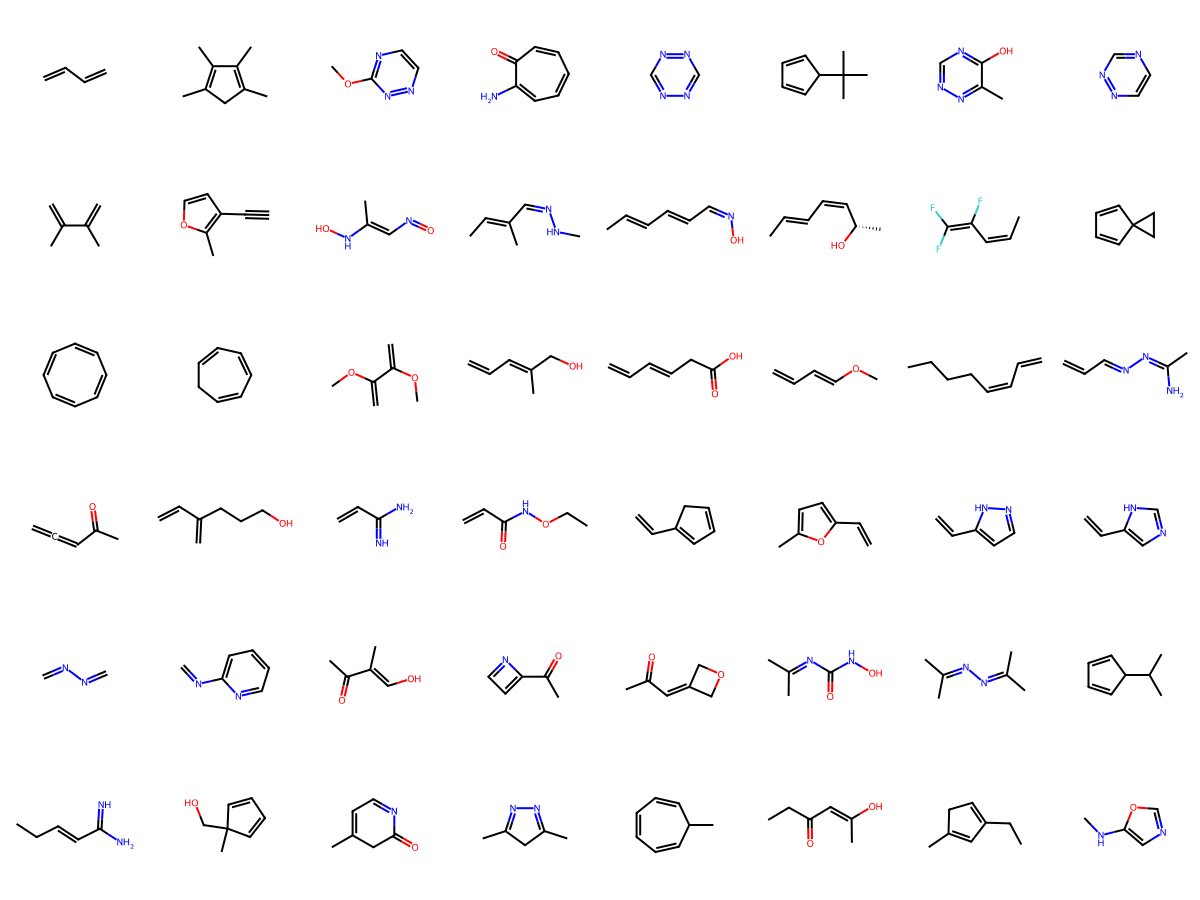

In [17]:
from rdkit.Chem import Draw
first_id = 0
# first_id += 50
legends = [str(each) for each in select_diene_csv["Index"][first_id:first_id + 48]]
legends = []
Draw.MolsToGridImage([Chem.MolFromSmiles(each) for each in select_diene_csv["Smiles"][first_id:first_id + 48]], molsPerRow=8, subImgSize=(150,150), legends=legends, useSVG=True)

In [28]:
len(select_ene_csv) / 10 / 15

11.926666666666668

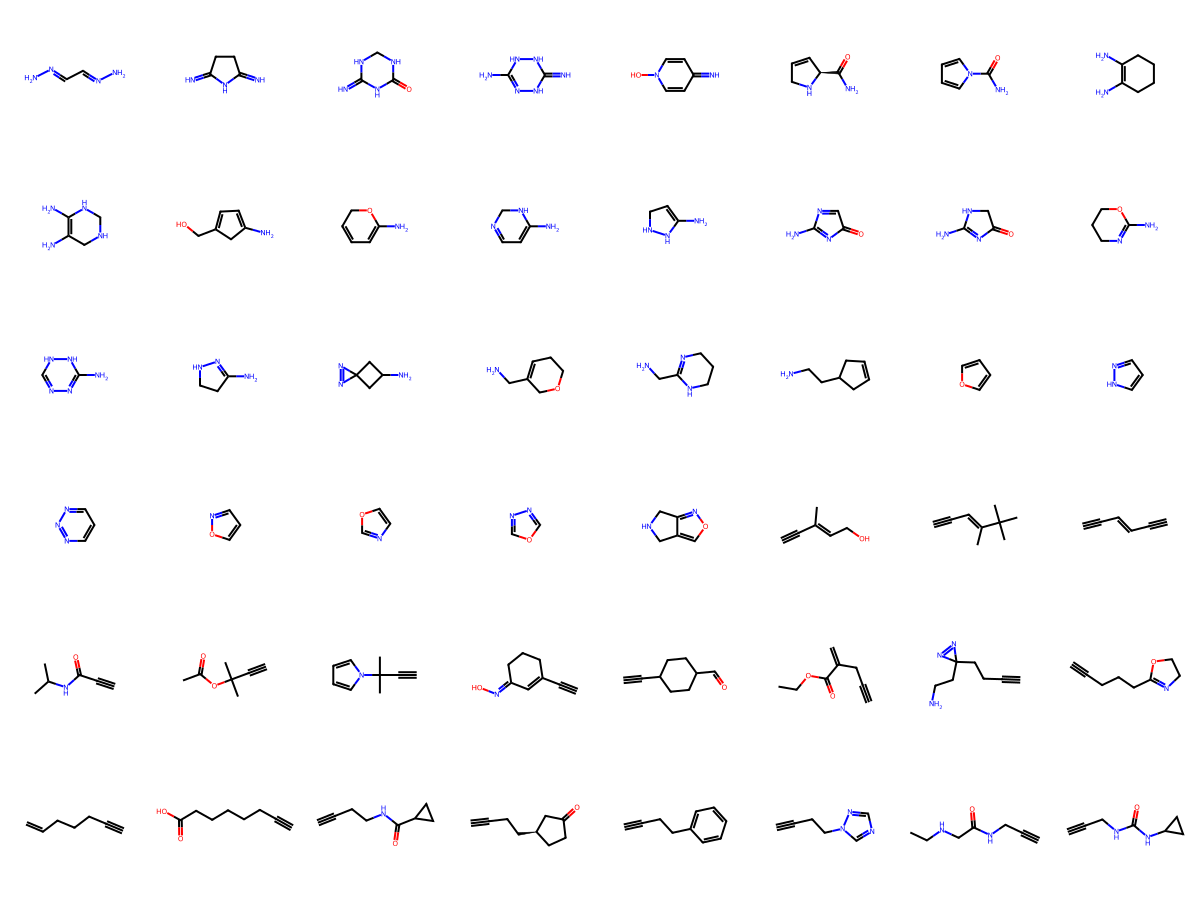

In [21]:
from rdkit.Chem import Draw
first_id = 0
first_id += 100
legends = [str(each) for each in select_ene_csv["Index"][first_id:first_id + 48]]
legends = []
Draw.MolsToGridImage([Chem.MolFromSmiles(each) for each in select_ene_csv["Smiles"][first_id:first_id + 48]], molsPerRow=8, subImgSize=(150,150), legends=legends, useSVG=True)

In [11]:
temp_df = pd.read_csv(REACTION_RESULT_CSV)
temp_df = temp_df.drop_duplicates(subset=['Diene_Index', 'Ene_Index'])
len(set(temp_df['Diene_Index'])), len(set(temp_df['Ene_Index']))

(718, 1789)

In [12]:
temp_df['Diene'].value_counts()[:10]

Diene
C1=CC=CC=CC=C1          186
C=CC(=C)CCCO            166
FC(F)=C(F)C(F)=C(F)F     99
C=CC=C                   97
C=NN=C                   81
C/C=C/C=C\[C@H](C)O      79
O=CC=O                   77
FC(F)=CC=C(F)F           65
NC1=CNCC=C1              53
C=C/C=C(\C)CO            53
Name: count, dtype: int64

In [13]:
temp_df['Ene'].value_counts()[:10]

Ene
O[C@@H]1C(F)=CC=C[C@@H]1O        33
C=CCN1C=CN(C=C)C1                28
C=C[C@H](O)C#CC(C)(C)C           28
C#C/C=C/C#C                      26
O=C1C=CCCNC(=O)N1                25
C=NC1C=CCC=C1                    24
F/C=C/CF                         22
C1=C[C@@H]2O[C@@H]2/C=C/C=C/1    22
C1=C\C/C=C\C/C=C\C/1             21
C#CCCC1(CCN)N=N1                 21
Name: count, dtype: int64